# Libs

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")

# PCA in Practice

In this notebook we explore Principal Component Analysis (PCA) from a practical machine learning perspective.

We focus on five professional lessons:

1. PCA must be fitted ONLY on training data.
2. PCA can improve generalisation and stability.
3. PCA does not always improve performance.
4. PCA may destroy interpretability.
5. Explained variance is not the same as predictive performance.

We will:
- Compare models with and without PCA
- Demonstrate data leakage
- Build proper ML pipelines
- Analyse PCA loading vectors
- Discuss interpretability trade-offs

# Dataset

We use the Wine dataset.

Why?
- Small and interpretable
- Several correlated variables
- Good for PCA demonstrations
- Multi-class classification problem

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
print(X.shape)

(178, 13)


# Correlation Between Variables

PCA is especially useful when variables are highly correlated.

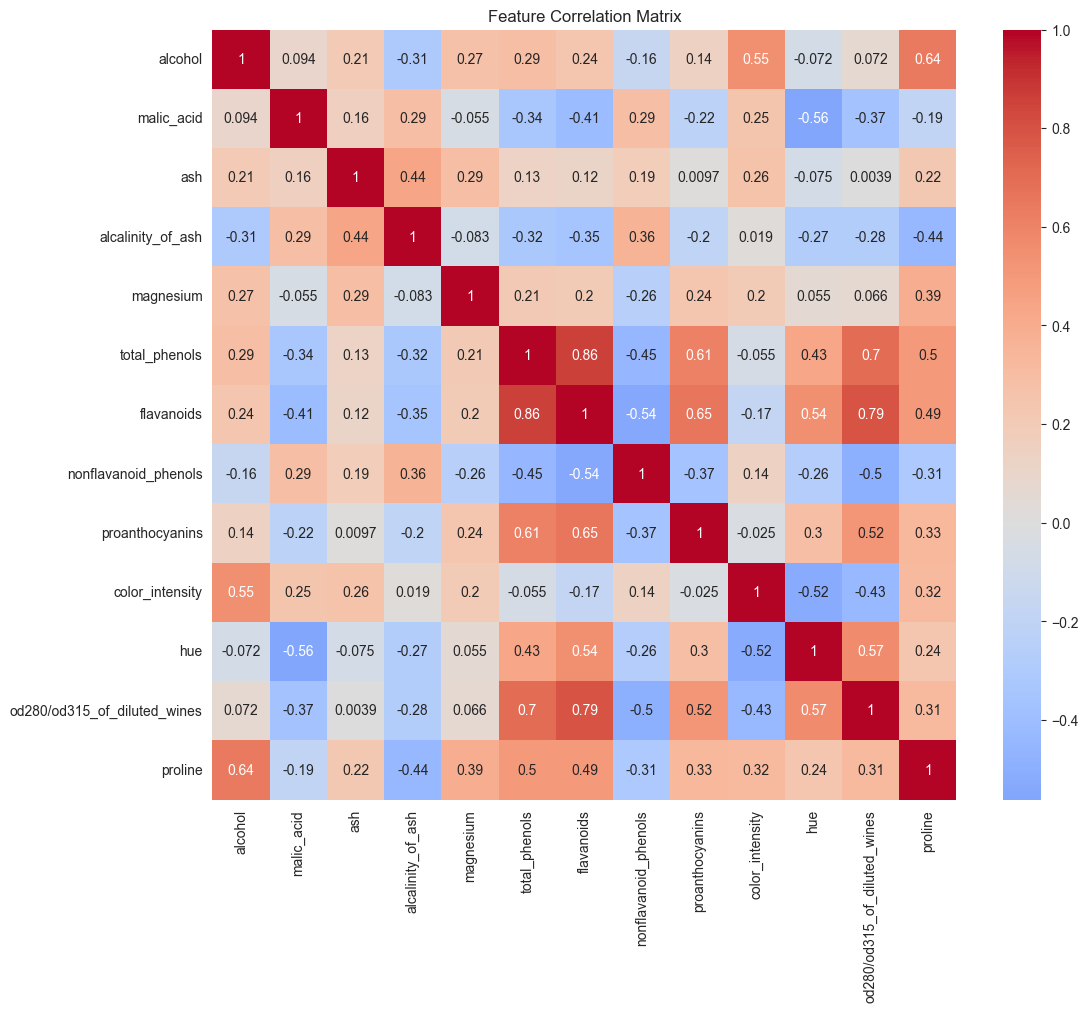

In [19]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
)

plt.title("Feature Correlation Matrix")
plt.show()

In [24]:
X.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')

# Baseline Model

We first train a model WITHOUT PCA.

This gives us a baseline performance.

In [27]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    baseline_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

print("Train Accuracy:", scores["train_score"].mean())
print("Test Accuracy :", scores["test_score"].mean())
print("Std Accuracy  :", scores["test_score"].std())

Train Accuracy: 1.0
Test Accuracy : 0.9833333333333332
Std Accuracy  : 0.013608276348795441


# WRONG APPROACH — DATA LEAKAGE

This is one of the most common PCA mistakes.

Here PCA is fitted BEFORE cross-validation.

This means:
- PCA sees the entire dataset
- Information from test folds leaks into training

This produces overly optimistic results.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)

# WRONG:
X_pca_wrong = pca.fit_transform(X_scaled)

scores_wrong = cross_val_score(
    LogisticRegression(max_iter=5000),
    X_pca_wrong,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Leaky PCA Accuracy:", scores_wrong.mean())

Leaky PCA Accuracy: 0.9833333333333332


# CORRECT APPROACH — PCA INSIDE THE PIPELINE

Now PCA is fitted separately inside each training fold.

This is the correct professional workflow.

In [28]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", LogisticRegression(max_iter=5000))
])

scores_pca = cross_validate(
    pca_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

print("Train Accuracy:", scores_pca["train_score"].mean())
print("Test Accuracy :", scores_pca["test_score"].mean())
print("Std Accuracy  :", scores_pca["test_score"].std())

Train Accuracy: 0.9943858957943466
Test Accuracy : 0.9777777777777779
Std Accuracy  : 0.020786985482077462


# Comparing PCA vs No PCA

PCA is not automatically beneficial.

We compare:
- Logistic Regression
- SVM
- Random Forest

With and without PCA.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    # Without PCA
    pipeline_no_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    score_no_pca = cross_val_score(
        pipeline_no_pca,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    # With PCA
    pipeline_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=5)),
        ("model", model)
    ])

    score_pca = cross_val_score(
        pipeline_pca,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    results.append({
        "Model": name,
        "Without PCA": score_no_pca.mean(),
        "With PCA": score_pca.mean()
    })

results_df = pd.DataFrame(results)

results_df

,Model,Without PCA,With PCA
0,Logistic Regression,0.983333,0.977778
1,SVM,0.983333,0.983333
2,Random Forest,0.977460,0.977778


# Discussion

Important observations:

- PCA may improve stability and generalisation
- PCA may reduce noise
- PCA may also remove useful information
- Tree-based models often benefit less from PCA

Why?

Because tree models already handle:
- redundancy
- irrelevant variables
- non-linear structures

# Explained Variance

PCA orders components according to variance explained.

But:
- High explained variance does NOT guarantee better prediction.

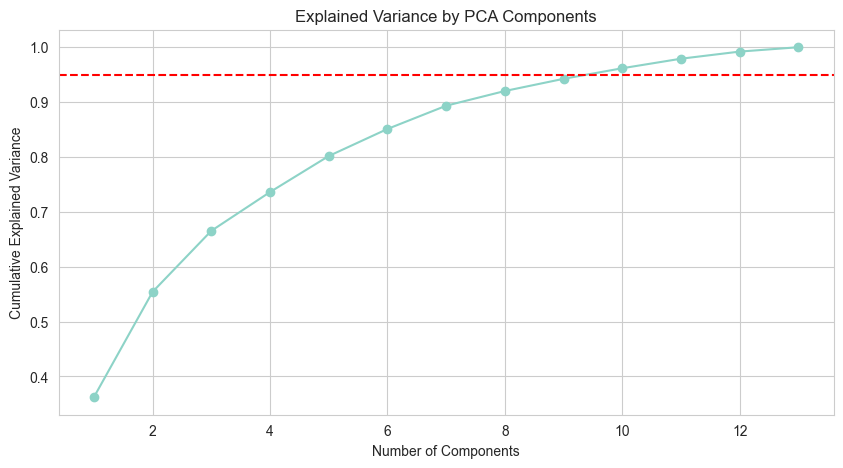

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#com todos os componentes
pca_full = PCA()

#transformacao do PCA X > PCs
X_pca_full = pca_full.fit_transform(X_scaled)

# variancia do componente dividida pela total (resultado em %)
explained = pca_full.explained_variance_ratio_
# print(explained)

#cria uma soma cumulativa
cumulative = np.cumsum(explained)
# print(cumulative)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative)+1),
    cumulative,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")

#linha de 95%
plt.axhline(
    y=0.95,
    color="red",
    linestyle="--"
)

plt.show()

In [33]:
for i, value in enumerate(cumulative):
    if value >= 0.95:
        print(f"95% variance retained with {i+1} components")
        break

95% variance retained with 10 components


# PCA Loadings

Loading vectors indicate how strongly each original variable contributes to a principal component.

However, interpretation must be done carefully.

Why?
- PCs are combinations of variables
- Signs may flip
- Components are sensitive to data changes
- PCA is not causal

In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#PC1=0.14⋅alcohol+0.25⋅flavanoids+...
#loadings

loadings = pd.DataFrame(
    pca.components_.T, #estava oriantado por linha dai faz o transpose para ter orientado por coluna
    columns=["PC1", "PC2"],
    index=X.columns
)

loadings

,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


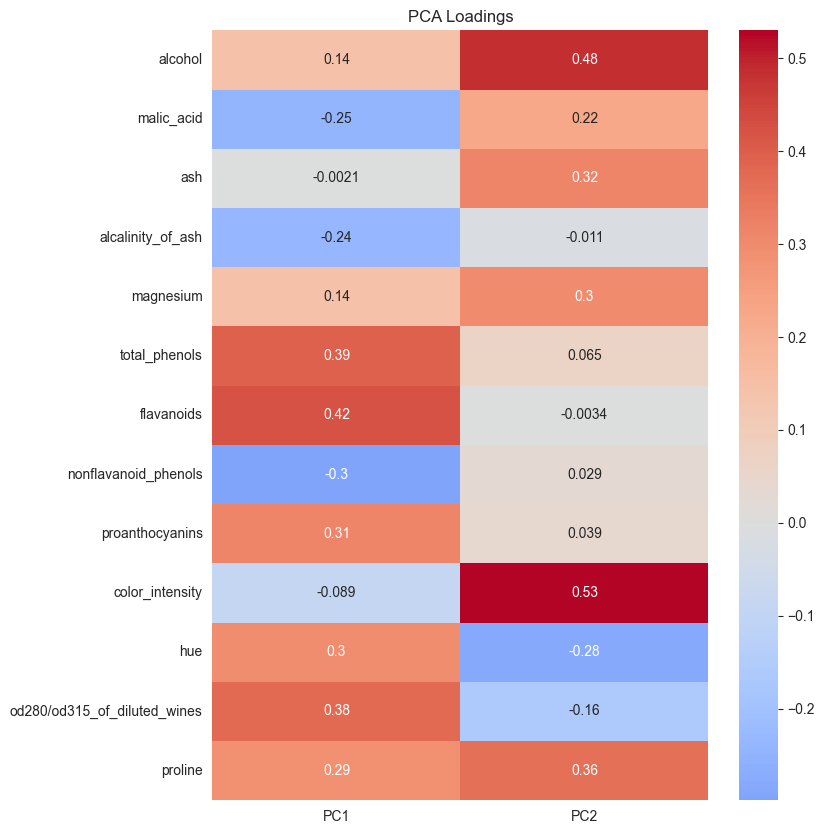

In [34]:
plt.figure(figsize=(8, 10))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings")
plt.show()

In [35]:
pc1_sorted = (
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
)

pc1_sorted

flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
hue                             0.296715
proline                         0.286752
malic_acid                      0.245188
alcalinity_of_ash               0.239320
alcohol                         0.144329
magnesium                       0.141992
color_intensity                 0.088617
ash                             0.002051
Name: PC1, dtype: float64

# Projection into 2 Dimensions

PCA is often useful for visualisation.

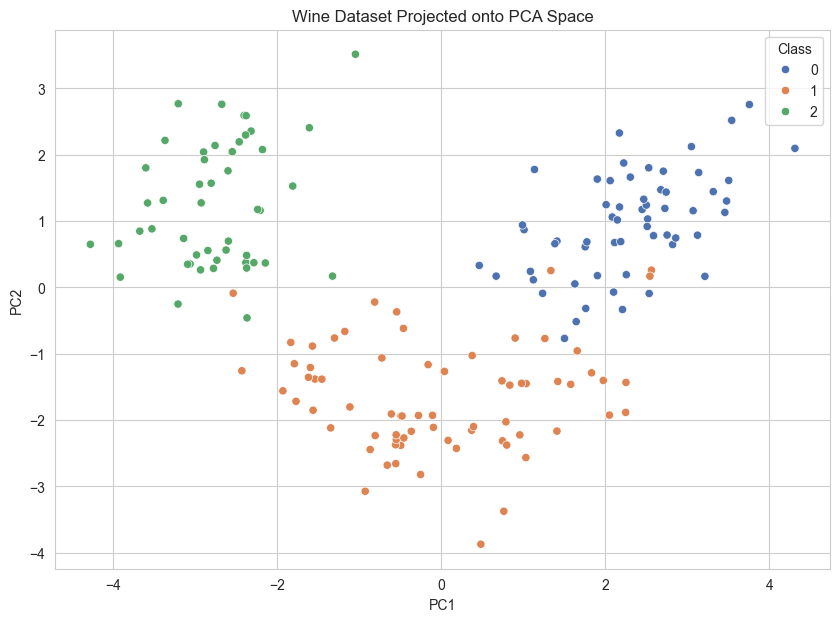

In [36]:
pca_vis = PCA(n_components=2)

X_vis = pca_vis.fit_transform(X_scaled)

vis_df = pd.DataFrame({
    "PC1": X_vis[:, 0],
    "PC2": X_vis[:, 1],
    "Class": y # vem dos dados anotados originais
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=vis_df,
    x="PC1",
    y="PC2",
    hue="Class",
    palette="deep"
)

plt.title("Wine Dataset Projected onto PCA Space")
plt.show()

# PCA and Overfitting

PCA can improve generalisation by:
- removing noisy dimensions
- reducing variance
- simplifying the hypothesis space

But:
- aggressive dimensionality reduction may remove signal

# Choosing the Number of Components

The number of PCA components is a hyperparameter.

We tune it using cross-validation.

In [16]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", LogisticRegression(max_iter=5000))
])

param_grid = {
    "pca__n_components": [2, 3, 5, 7, 10, 12]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy"
)

grid.fit(X, y)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)

Best Parameters:
{'pca__n_components': 10}

Best Accuracy:
0.9833333333333332


# Professional Lessons

## 1. PCA must be inside the pipeline
Otherwise data leakage occurs.

## 2. PCA is not automatically beneficial
Always compare with a baseline.

## 3. Explained variance is not predictive performance
Variance preservation and prediction are different objectives.

## 4. PCA may improve stability and generalisation
Especially in high-dimensional noisy settings.

## 5. PCA reduces interpretability
Principal components are abstract combinations of variables.

## 6. Tree models often benefit less from PCA
Because trees already handle redundancy well.